In [55]:
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
# loading the Superstore dataset
# windows-1252 encoding was required — default utf-8 raised a read error
df = pd.read_csv('/content/drive/MyDrive/Planilhas - Dados/Projeto 03 - Superstore/Sample - Superstore.csv', encoding='windows-1252')

# converting date columns from string to datetime
# so we can extract year and month later
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [63]:
# overall sales and profit totals to get a general sense of scale
print(df['Sales'].sum())
print(df['Profit'].sum())

# Order ID repeats because a single order can contain multiple products
print(f'Unique orders (Order ID): {df["Order ID"].nunique()}')

2297200.8603000003
286397.0217
Unique orders (Order ID): 5009


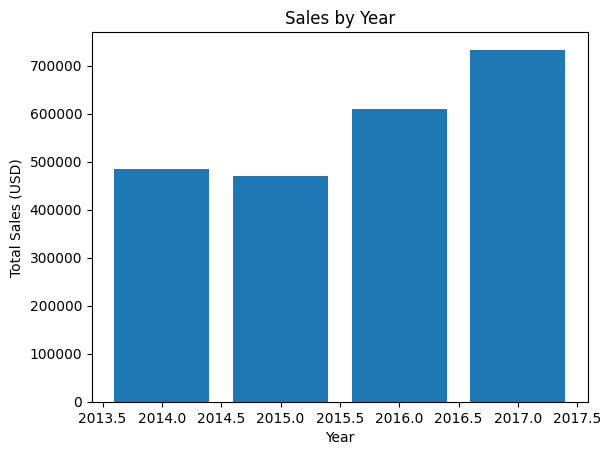

In [69]:
# creating the year column and analyzing sales growth over time
df['Year'] = df['Order Date'].dt.year

vendas_ano = df.groupby('Year')['Sales'].sum()

plt.bar(vendas_ano.index, vendas_ano.values)
plt.xlabel('Year')
plt.ylabel('Total Sales (USD)')
plt.title('Sales by Year')
plt.show()

# sales grew consistently from 2014 to 2017, accelerating in the last two years

Year
2014     7581
2015     7979
2016     9837
2017    12476
Name: Quantity, dtype: int64


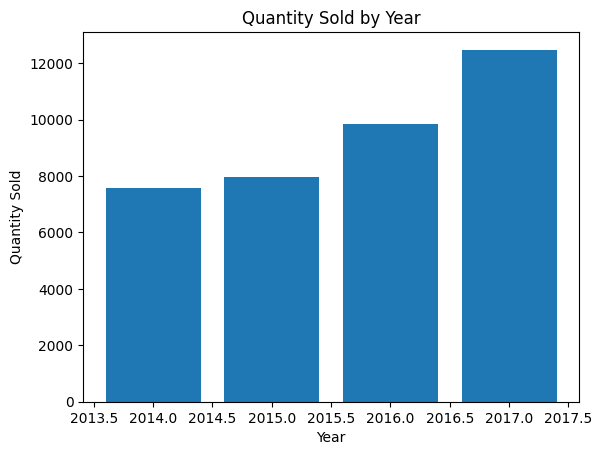

In [70]:
# checking if sales growth came with more units sold
# or if it was just a price effect
quantidade_ano = df.groupby('Year')['Quantity'].sum()

print(quantidade_ano)

plt.bar(quantidade_ano.index, quantidade_ano.values)
plt.xlabel('Year')
plt.ylabel('Quantity Sold')
plt.title('Quantity Sold by Year')
plt.show()

# quantity also increased — confirming real volume growth, not just price inflation

Year
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64


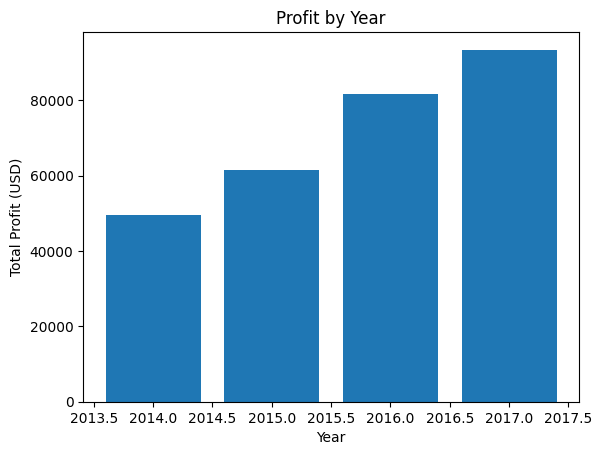

In [71]:
# checking if profit followed the same growth trend as sales
profit_ano = df.groupby('Year')['Profit'].sum()

print(profit_ano)

plt.bar(profit_ano.index, profit_ano.values)
plt.xlabel('Year')
plt.ylabel('Total Profit (USD)')
plt.title('Profit by Year')
plt.show()

Year
2014    0.118112
2015    0.117567
2016    0.129789
2017    0.115981
Name: Profit Margin, dtype: float64


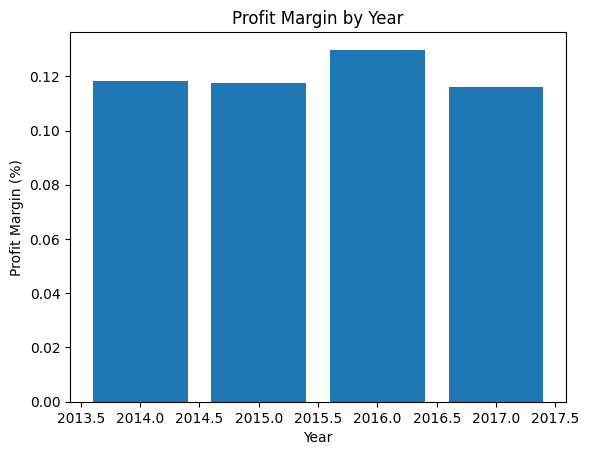

In [72]:
# key metric: profit margin by year
# to check whether the company became more efficient or just sold more
df['Profit Margin'] = df['Profit'] / df['Sales']

margem_ano = df.groupby('Year')['Profit Margin'].mean()

print(margem_ano)

plt.bar(margem_ano.index, margem_ano.values)
plt.xlabel('Year')
plt.ylabel('Profit Margin (%)')
plt.title('Profit Margin by Year')
plt.show()

# margin stayed around 12% across all four years
# the company scaled in volume but not in efficiency

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


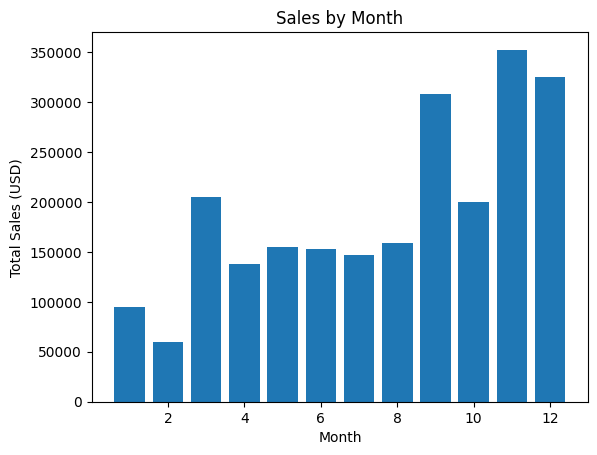

In [73]:
# creating the month column to analyze seasonality
df['Month'] = df['Order Date'].dt.month

vendas_mes = df.groupby('Month')['Sales'].sum()

print(vendas_mes)

plt.bar(vendas_mes.index, vendas_mes.values)
plt.xlabel('Month')
plt.ylabel('Total Sales (USD)')
plt.title('Sales by Month')
plt.show()

# sales show a clear seasonal pattern — consistently higher in Q4 (Sep–Dec)

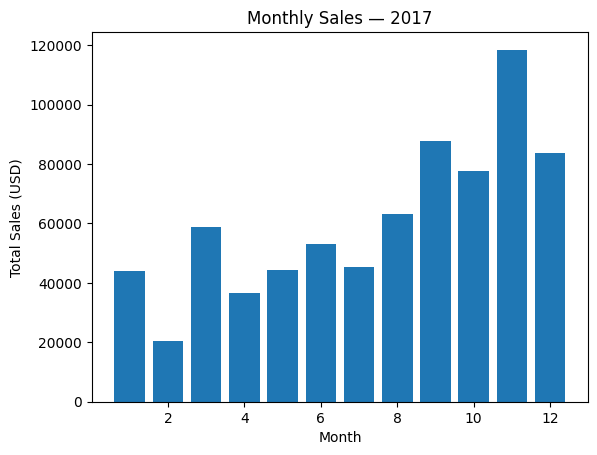

In [74]:
# confirming the seasonal pattern by looking at 2017 in isolation
vendas_mes_ano = df.groupby(['Month', 'Year'])['Sales'].sum().reset_index()

vendas_2017 = vendas_mes_ano[vendas_mes_ano['Year'] == 2017]

plt.bar(vendas_2017['Month'], vendas_2017['Sales'])
plt.xlabel('Month')
plt.ylabel('Total Sales (USD)')
plt.title('Monthly Sales — 2017')
plt.show()

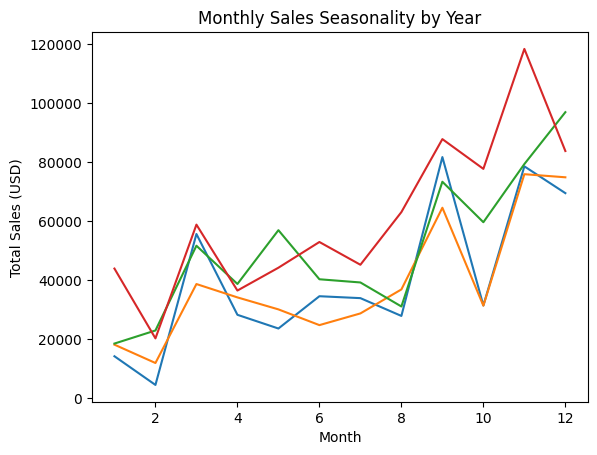

In [75]:
# plotting all years together to compare seasonal behavior across the period
vendas_mes_ano = df.groupby(['Month', 'Year'])['Sales'].sum().unstack()

plt.plot(vendas_mes_ano)
plt.xlabel('Month')
plt.ylabel('Total Sales (USD)')
plt.title('Monthly Sales Seasonality by Year')
plt.show()

# the Q4 surge repeats every year — demand starts picking up around September
# likely driven by end-of-year purchasing cycles

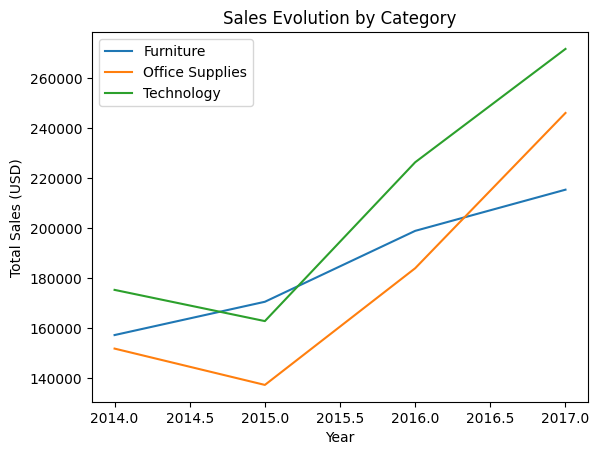

In [76]:
# how each category evolved year over year
vendas_categorias_por_ano = df.groupby(['Category', 'Year'])['Sales'].sum().unstack()
vendas_categorias_por_ano = vendas_categorias_por_ano.T

plt.plot(vendas_categorias_por_ano)
plt.xlabel('Year')
plt.ylabel('Total Sales (USD)')
plt.title('Sales Evolution by Category')
plt.legend(vendas_categorias_por_ano.columns)
plt.show()